Вам предстоит решить задачу классификации сложных цветных изображений — датасет **CIFAR-10**.
В нем 10 классов: самолеты, автомобили, птицы, кошки, олени, собаки, лягушки, лошади, корабли, грузовики.

**Ваша цель:** Пробить "потолок" точности (`accuracy`) в **50%** на тестовой выборке.
**Главное правило:** Запрещено использовать любые слои, кроме `Dense`, `Dropout`, `Input` и слоев регуляризации. Никаких сверточных нейросетей (CNN)! Только полносвязные сети.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers

# Вспомогательная функция для отрисовки графиков
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()

    plt.show()

### Шаг 1: Загрузка и подготовка данных
Изображения цветные, размер 32x32 пикселя, 3 канала (RGB).
1. Загрузите датасет CIFAR-10.
2. "Распрямите" изображения (Flatten) в плоский вектор. Какова будет его размерность?
3. Масштабируйте данные (от 0 до 1).
4. Закодируйте метки классов (y) методом One-Hot Encoding.

In [ ]:
# Загрузка данных
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

X_train = X_train.reshape((50000, 32*32*3))
X_test = X_test.reshape((10000, 32*32*3))

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
y_train_enc = enc.fit_transform(y_train)
y_test_enc = enc.transform(y_test)

### Шаг 2: Модель "Слабое звено" (Недообучение)
Давайте посмотрим, что будет, если дать сложной задаче слишком простую модель.
1. Создайте сеть всего с одним скрытым слоем на **32 нейрона** (активация `relu`).
2. Добавьте выходной слой. *Внимание! Подумайте, какая функция активации и loss-функция нужны для 10 классов.*
3. Обучите на 15 эпохах.
4. Постройте графики. Сделайте выводы: хватает ли емкости этой сети, чтобы уловить закономерности в цветных фото?

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │        98,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,666 (385.41 KB)

 Trainable params: 98,666 (385.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3621 - loss: 1.8755 - val_accuracy: 0.3909 - val_loss: 1.7650
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4356 - loss: 1.6325 - val_accuracy: 0.4171 - val_loss: 1.6765
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4627 - loss: 1.5412 - val_accuracy: 0.4438 - val_loss: 1.6199
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4809 - loss: 1.4722 - val_accuracy: 0.4468 - val_loss: 1.5942
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4941 - loss: 1.4434 - val_accuracy: 0.4510 - val_loss: 1.5717
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5055 - loss: 1.4114 - val_accuracy: 0.4660 - val_loss: 1.5646
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5125 - loss: 1.3861 - val_accuracy: 0.4639 - val_loss: 1.5549
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5194 - loss: 1.3652 - val_accuracy: 0.

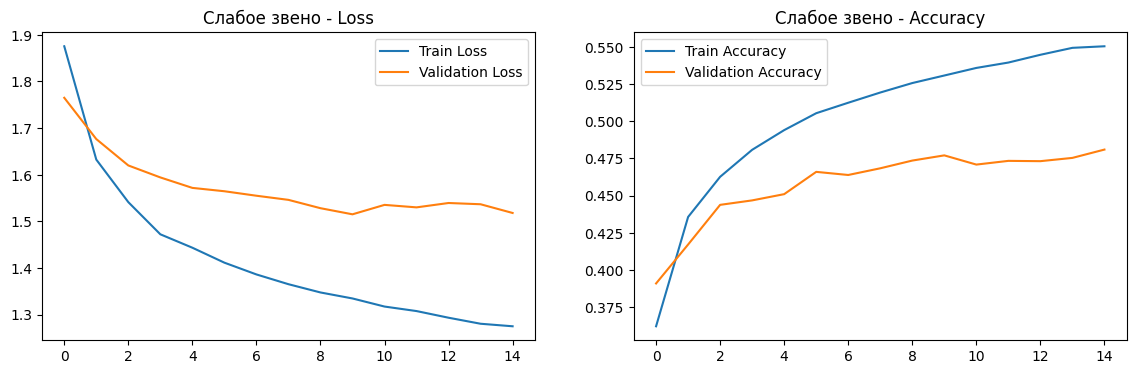

In [ ]:
# Размер входа
input_dim = 3072
num_classes = 10

# Создание модели
model = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(input_dim,)),
    layers.Dense(num_classes, activation='softmax')
])

# Компиляция
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Обучение на 15 эпохах
history = model.fit(
    X_train_scaled,
    y_train_enc,
    epochs=15,
    batch_size=128,
    validation_split=0.2
)

plot_history(history, 'Слабое звено')

Вывод: нейросети не хватает мощности, так как loss/accuracy на валидации в какой-то момент застревают на одном уровне, а на трейне идет их рост.

### Шаг 3: Модель "Зубрила" (Переобучение)
Простая модель не справилась (метрики застряли на ~30%). Дадим сети больше мощности!
1. Постройте глубокую полносвязную сеть (например, скрытые слои на **1024, 512 и 256 нейронов**).
2. **Не используйте** Dropout или регуляризацию.
3. Обучите на 25 эпохах.
4. Постройте графики. **Вопрос для размышления:** На какой эпохе сеть перестала учиться обобщать и начала просто "зазубривать" тренировочные данные? Как вы это поняли по графику Loss?

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.3943 - loss: 1.7281 - val_accuracy: 0.4346 - val_loss: 1.6044
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4726 - loss: 1.4912 - val_accuracy: 0.4681 - val_loss: 1.5015
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5162 - loss: 1.3758 - val_accuracy: 0.4720 - val_loss: 1.5186
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5443 - loss: 1.2900 - val_accuracy: 0.4995 - val_loss: 1.4545
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5708 - loss: 1.2083 - val_accuracy: 0.5047 - val_loss: 1.4370
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5921 - loss: 1.1475 - val_accuracy: 0.5060 - val_loss: 1.4560
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6220 - loss: 1.0674 - val_accuracy: 0.5066 - val_loss: 1.4881
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6455 - loss: 1.0015 - val_accuracy: 0

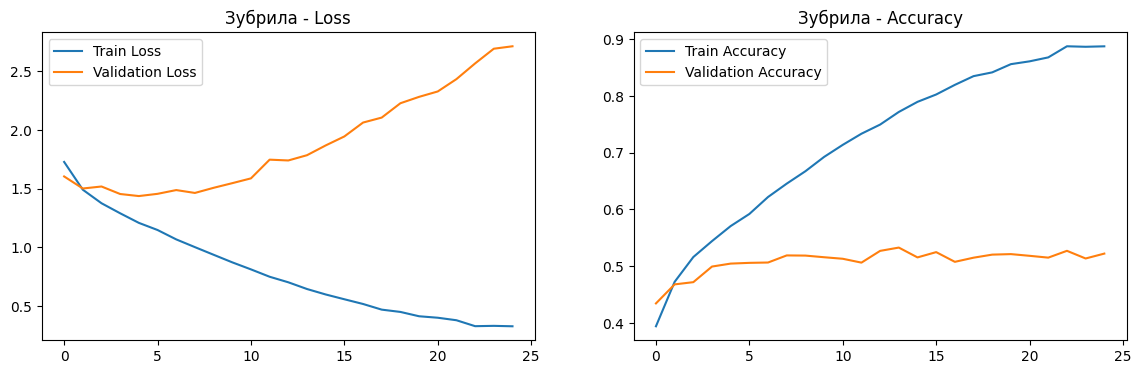

In [ ]:
input_dim = 3072
num_classes = 10

model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(input_dim,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Обучение на 25 эпохах
history = model.fit(
    X_train_scaled,
    y_train_enc,
    epochs=25,
    batch_size=128,
    validation_split=0.2
)

plot_history(history, 'Зубрила')

Вывод: видим переобучение по резкому росту val loss при снежении train loss.

### Шаг 4: Вызываем подкрепление (Callbacks & Regularization)

Теперь применим весь арсенал. Создайте новую архитектуру, взяв за основу сеть из Шага 3, но добавив инструменты удержания:
1. **Dropout**: Добавьте слои `Dropout` (например, 0.3 или 0.4) после крупных `Dense` слоев.
2. **L2 Регуляризация**: (Опционально) добавьте `kernel_regularizer='l2'` в один из слоев.
3. **Callbacks**: При вызове метода `.fit()` передайте список из трех коллбэков:
   - `EarlyStopping`: остановка, если `val_accuracy` не растет 8 эпох (`restore_best_weights=False`, т.к. будем сохранять чекпоинтом).
   - `ReduceLROnPlateau`: уменьшение learning rate (factor=0.5), если метрика застряла на плато на 3 эпохи.
   - `ModelCheckpoint`: сохраняйте **только лучшие** веса в файл `best_cifar10_model.keras`.
4. Запустите обучение на 70 эпох. Коллбэки сами остановят процесс в нужный момент.

In [ ]:
# Модель
input_dim = 3072
num_classes = 10

model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(input_dim,)),
    layers.Dropout(0.4),

    layers.Dense(512, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),  # L2 (опционально)
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Колбэки
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=False
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        'best_cifar10_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

Epoch 1/70
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2802 - loss: 2.7614
Epoch 1: val_accuracy improved from None to 0.41150, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3276 - loss: 2.4295 - val_accuracy: 0.4115 - val_loss: 1.9867 - learning_rate: 0.0010
Epoch 2/70
779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4003 - loss: 1.9748
Epoch 2: val_accuracy improved from 0.41150 to 0.46140, saving model to best_cifar10_model.keras

Epoch 2: finished saving model to best_cifar10_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4064 - loss: 1.9198 - val_accuracy: 0.4614 - val_loss: 1.7241 - learning_rate: 0.0010
Epoch 3/70
775/782 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4388 - loss: 1.7668
Epoch 3: val_accuracy did not improve from 0.46140
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4364 - loss: 1.7543 - val_accuracy: 0.4593 

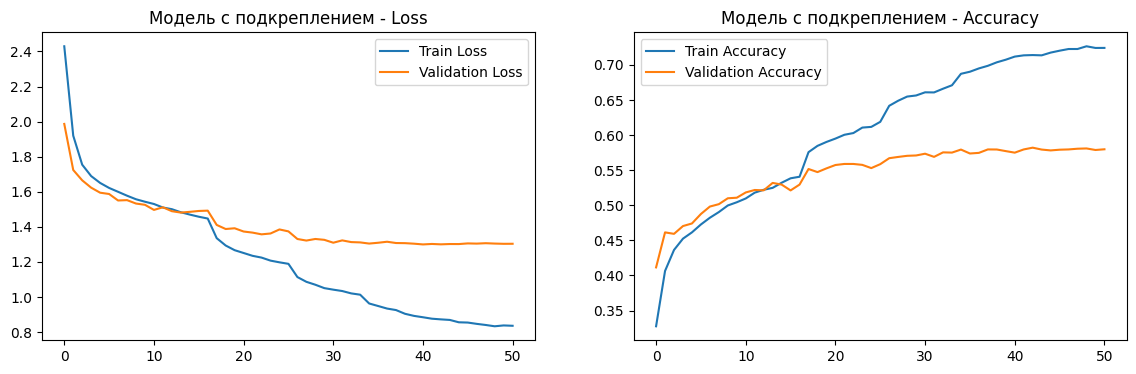

In [ ]:
# Обучение и графики
history = model.fit(
    X_train_scaled,
    y_train_enc,
    epochs=70,
    batch_size=64,
    validation_data=(X_test_scaled, y_test_enc),
    callbacks=callbacks
)
plot_history(history, 'Модель с подкреплением')

### Шаг 5: Оценка результата
1. Загрузите лучшие веса из сохраненного файла (`keras.models.load_model`).
2. Сделайте `.predict()` на тестовой выборке (`X_test`).
3. Выведите итоговое значение `accuracy_score`. Смогли ли вы преодолеть барьер в 50%?
4. Напишите краткий вывод: какой инструмент по вашему мнению оказал наибольшее влияние на результат?

In [ ]:
from tensorflow.keras.models import load_model
# Загрузили модель
model = load_model('best_cifar10_model.keras')

# Предсказания
import numpy as np
y_pred = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_enc, axis=1)

# Метрики
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_true, y_pred_classes)
print("Test accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Test accuracy: 0.5821


Вывод: в ходе эксперимента удалось преодолеть порог в 50% точности на тестовой выборке. Наибольшее влияние на итоговый результат оказал Dropout, так как он существенно снизил переобучение модели, заставляя её обучаться более устойчиво и быстрее. Также важную роль сыграл EarlyStopping, который остановил обучение в момент, когда качество на валидации перестало улучшаться. L2-регуляризация оказала дополнительный стабилизирующий эффект, но её влияние было менее заметным по сравнению с Dropout.